# redshift (z) 
$\rightarrow$ **calcul du redshift de galaxies**

## le cours 

3C 273 est un Quasar de type FSRQ (Flat Spectrum Radio Quasar)
- C'est un Noyau Galactique Actif (AGN) extrêmement lumineux.
- Le spectre de 3C 273 est dominé par des raies d'émission très larges ( $\text{H}\alpha$, $\text{H}\beta$, $\text{MgII}$, $\text{CIII}]$...).
- Cette largeur indique un gaz se déplaçant à des milliers de kilomètres par seconde dans la Région à Raies Larges (BLR).

-> Le gaz autour du trou noir tourne à plus de 3000 km/s. C'est ce qui différencie un Quasar (raies larges) d'une galaxie normale (raies fines).



NGC 7215 est classée comme une Galaxie de Seyfert de Type 1.5.
- C'est un type de galaxie dont le noyau est très brillant (un Noyau Galactique Actif ou AGN).
- Ce noyau est alimenté par un trou noir supermassif (SMBH) qui accrète de la matière.
- La classification **Seyfert** se base sur l'apparence des raies d'émission dans le spectre, qui proviennent de différentes régions autour du trou noir :
    - Raies Étroites (NLR - Narrow Line Region) : Gaz éloigné qui donne des raies fines (comme $[\text{OIII}]$ et $[\text{SII}]$) .
    - Raies Larges (BLR - Broad Line Region) : Gaz très proche du trou noir, se déplaçant très rapidement, ce qui élargit fortement les raies d'hydrogène


On va aussi estimer la masse du trou noir via le théorème du Viriel, où la masse est liée à la vitesse du gaz ($V$) et au rayon de la BLR ($R_{BLR}$)

## les données

|||
|---|---|
|OBJECT|	3c273|
|EXPTIME2|	5 x 60 s|
|BSS_ITRP|	500|
|SPE_RPOW|	500|
|BSS_VHEL|	0|
|DATE-OBS|	2017-04-07|
|GEO_LONG|	-1.630000|
|GEO_LAT|	48.120000|
|GEO_ELEV|	55|
|BSS_SITE|	CALC|
|BSS_INST|	ED80 + Dados200 + 25mic + ATIK 420m|
|||


## création du dashboard
- lancer la cellule suivante
- souris sur '**Colormap**', bouton droit, menu "**create new view for cell output**"
- déplacer le nouvel onglet créé '**Output View**' pour le garder visible pendant que vous naviguez et exécutez les cellules de code

En cas de souci d'affichage $\rightarrow$  '**CTRL-R**'


In [1]:
%matplotlib widget
from spectro_dashboard import SpectroDashboard

db = SpectroDashboard()
db.show()


# chargement du spectre

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from specutils import Spectrum
from astropy.modeling.models import Gaussian1D, Voigt1D, Lorentz1D, Const1D
from astropy.modeling.fitting import LevMarLSQFitter # L'outil de fit correct

from specutils.fitting import fit_generic_continuum
from astropy.modeling.models import Polynomial1D # Exemple de modèle de fit
from specutils import SpectralRegion
from astropy.stats import mad_std
from specutils.analysis import snr, snr_derived
from specutils.spectra import SpectralRegion

from astropy.constants import c
from astropy.cosmology import Planck18

# on affiche le spectre de la galaxie

db.clear_spectra()

# lecture de fichiers DAT (csv)
#spec_name = 'data/plouis/_ngc7215-_20161228_896_P.Louis.dat'
#spec_name = 'data/plouis/_ngc4151_20170121_974_P.Louis.dat'
spec_name = 'data/plouis/_3c273_20170407_870_PLouis.dat'

_spc_array = np.loadtxt(spec_name)
_spec1d = Spectrum(spectral_axis=_spc_array[:,0] * u.Unit('Angstrom'), 
                 flux=_spc_array[:,1] * u.Unit('mJy')
                         )

db.show_spectrum(_spec1d.wavelength, _spec1d.flux, label=spec_name)


--> Affichage du spectre data/plouis/_3c273_20170407_870_PLouis.dat : dispersion=0.8421 Å/px


# retrait du continuum

In [3]:
#db.clear_spectra()

# on reprend le spectre créé ci-dessus
spectrum = _spec1d #Spectrum1D(flux=flux, spectral_axis=wavelength)

continuum_model_fit = Polynomial1D(degree=3) 

# on défini les zones à exclure
windows_tuples = [
    (4850 * u.Angstrom, 4900 * u.Angstrom), # Exclusion de Hβ
    (4950 * u.Angstrom, 5040 * u.Angstrom)  # Exclusion des [OIII]
]

# on créé les deux regions
exclusion_regions = [SpectralRegion(start, end) for start, end in windows_tuples]

# on ajuste le modèle uniquement aux régions qui NE SONT PAS dans exclusion_windows.
fitted_continuum = fit_generic_continuum(
    spectrum,
    model=continuum_model_fit,
    exclude_regions=exclusion_regions
)

# Évaluation du modèle ajusté sur l'intégralité du spectre
continuum_flux_to_subtract = fitted_continuum(spectrum.spectral_axis)

# Obtention du spectre net
spectrum_sans_cont = Spectrum(
    flux=spectrum.flux / continuum_flux_to_subtract,
    spectral_axis=spectrum.spectral_axis
)

region_continuum = SpectralRegion(4500*u.Angstrom, 4700*u.Angstrom)

db.show_spectrum(spectrum.spectral_axis.to(u.Angstrom).value, continuum_flux_to_subtract.value, label='continuum')
db.show_spectrum(spectrum_sans_cont.spectral_axis, spectrum_sans_cont.flux, label='continuum retiré')


--> Affichage du spectre continuum : dispersion=0.8421 Å/px
--> Affichage du spectre continuum retiré : dispersion=0.8421 Å/px


# ajustement 

In [5]:
# 
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.modeling import models
from specutils import Spectrum1D, SpectralRegion
from specutils.manipulation import extract_region
from specutils.fitting import fit_lines
from specutils.analysis import centroid, fwhm, equivalent_width, snr, snr_derived


lambda_rest = 5006.84 * u.Angstrom # OIII
lambda_rest = 4861.35 * u.Angstrom # Hbeta
region_cont = SpectralRegion(4250.0 * u.AA, 4900.0 * u.AA)
fwhm_neon_pix = 3.11  # largeur raie néon en px, retourné par ISIS
disp_physique = 0.8421 # dispersion du DADOS200, retourné par ISIS
fwhm_inst_a = fwhm_neon_pix * disp_physique  # Résolution en Angströms
err_pos = fwhm_inst_a / 10.0                 
#print(f"{err_pos=}")
err_v = c * (err_pos / (2 * lambda_rest))         # 
#print(f"{err_v=}")

sub_spectrum = extract_region(spectrum_sans_cont, region_cont)
flux_zone = sub_spectrum.flux.value
snr_reel = np.mean(flux_zone) / np.std(flux_zone)
print(f"SNR réel : {snr_reel:.2f}")

#snr_val = snr_derived(spectrum_sans_cont, region_cont)
#print(f"SNR auto (faux): {snr_val:.2f}")

# on prépare ldes valeurs d'aide pour le fitter
y_min = np.min(spectrum_sans_cont.flux)
y_max = np.max(spectrum_sans_cont.flux)
amp_em_guess = y_max - y_min

# On définit le modèle : Gaussienne + Continuum (Const1D)
g_init = models.Gaussian1D(amplitude=amp_em_guess, mean=lambda_rest+800*u.AA, stddev=5*u.AA) + models.Const1D(1.0)
g_fit = fit_lines(spectrum_sans_cont, g_init)

# Extraction des résultats du fit
center_fit = g_fit[0].mean.value
fwhm_fit = g_fit[0].fwhm.value

# Incertitudes
delta_lambda = np.mean(np.diff(spectrum_sans_cont.spectral_axis))       # pas spectral (dispersion)
n_pts = fwhm_fit / delta_lambda

err_fwhm_fit = (2.0 * fwhm_fit) / snr_reel
err_center_fit = fwhm_fit / (2.35 * snr_reel * np.sqrt(n_pts))

print(f"Centroïde : {center_fit:.2f} +/- {err_pos:.2f} Å")
print(f"FWHM      : {fwhm_fit:.2f} +/- {fwhm_inst_a:.2f} Å")

# vitesse radiale 
c_km_s = 299792.458

delta_lambda_obs = center_fit - lambda_rest.value
vr = c_km_s * (delta_lambda_obs / lambda_rest.value)
err_vr = c_km_s * (err_center_fit / lambda_rest.value)

# on s'assure que tout est en unités Astropy pour éviter les erreurs de <Quantity>
lambda_obs = center_fit * u.AA

# Calcul du Redshift (z)
# z est adimensionnel : (AA - AA) / AA
z_obs = (lambda_obs - lambda_rest) / lambda_rest
z_obs_val = z_obs.decompose().value 

# Incertitudes sur z
# err_center_fit doit avoir l'unité u.AA pour le calcul
err_z = (err_center_fit * u.AA) / lambda_rest
err_z_val = err_z.decompose().value

# Vitesse Radiale (Récession)
# On utilise le z pour la vitesse de récession
vr = (z_obs_val * c_km_s) * (u.km / u.s)
err_vr = (err_z_val * c_km_s) * (u.km / u.s)

# Distance Cosmologique (modèle Planck18)
distance_mpc_obs = Planck18.luminosity_distance(z_obs_val)

# Calcul des bornes pour l'incertitude sur la distance
z_min, z_max = z_obs_val - err_z_val, z_obs_val + err_z_val
dist_min = Planck18.luminosity_distance(z_min)
dist_max = Planck18.luminosity_distance(z_max)
err_dist_mpc = (dist_max - dist_min) / 2

# on récupère les valeurs numériques sans unités pour être sûr
v_lambda_obs = center_fit if not hasattr(center_fit, 'value') else center_fit.value
v_fwhm = fwhm_fit if not hasattr(fwhm_fit, 'value') else fwhm_fit.value
v_lambda_rest = lambda_rest.value
v_snr = snr_reel
v_internal = (v_c * v_fwhm / v_lambda_obs)

# on recalcul manuel propre l'erreur sur le centre (Formule de Cayrel modifiée)
v_delta_lambda = np.mean(np.diff(spectrum_sans_cont.spectral_axis.value))
v_n_pts = v_fwhm / v_delta_lambda
v_err_center = v_fwhm / (2.35 * v_snr * np.sqrt(v_n_pts))

# o,n propagation sur z, VR et Distance
v_z = (v_lambda_obs - v_lambda_rest) / v_lambda_rest
v_err_z = v_err_center / v_lambda_rest

v_c = 299792.458
v_vr = v_z * v_c
v_err_vr = v_err_z * v_c

# calcul de l'erreur sur la FWHM en km/s
v_err_fwhm = v_fwhm / v_snr  # Approximation classique de l'erreur sur la largeur
v_err_dispersion = (v_c * v_err_fwhm) / v_lambda_obs

v_dist = Planck18.luminosity_distance(v_z).value
v_err_dist = (Planck18.luminosity_distance(v_z + v_err_z).value - 
              Planck18.luminosity_distance(v_z - v_err_z).value) / 2

print(f"Redshift (z)      : {v_z:.6f} +/- {v_err_z:.6f}")
print(f"Vitesse Radiale   : {v_vr:.2f} +/- {v_err_vr:.2f} km/s")
print(f"Distance (D_L)    : {v_dist:.2f} +/- {v_err_dist:.2f} Mpc")
print(f"Dispersion (FWHM) : {v_internal:.2f} +/- {v_err_dispersion:.2f} km/s")


db.clear_spectra()

# on recharge le spectre sans le continnum
db.show_spectrum(spectrum_sans_cont.spectral_axis, spectrum_sans_cont.flux, label='continuum retiré')
# on affiche le fit
l_rest = db.ax_spec.axvline(lambda_rest.value, color='red', ls='--', alpha=1, lw=1)
y_fit = g_fit(spectrum_sans_cont.spectral_axis)
db.show_spectrum(
    spectrum_sans_cont.spectral_axis,
    y_fit,
    label='Modèle ajusté'
)


SNR réel : 16.13
Centroïde : 5633.76 +/- 0.26 Å
FWHM      : 57.43 +/- 2.62 Å
Redshift (z)      : 0.158888 +/- 0.000038
Vitesse Radiale   : 47633.51 +/- 11.32 km/s
Distance (D_L)    : 784.85 +/- 0.20 Mpc
Dispersion (FWHM) : 3056.27 +/- 189.50 km/s
--> Affichage du spectre continuum retiré : dispersion=0.8421 Å/px
--> Affichage du spectre Modèle ajusté : dispersion=0.8421 Å/px


# résidus

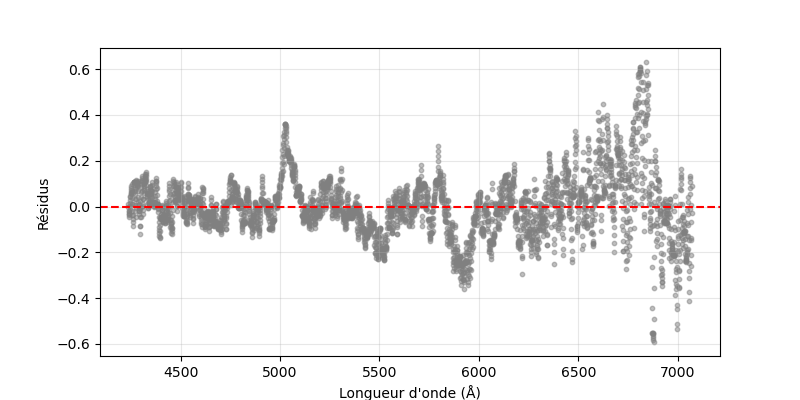

In [6]:
# on récupère les résidus en divisant le brut par le fit
residus = spectrum_sans_cont.flux - y_fit

# on affiche
fig, ax = plt.subplots(1, 1, figsize=(8, 4))#, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax.scatter(spectrum_sans_cont.spectral_axis, residus, s=10, color='gray', alpha=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_ylabel('Résidus')
ax.set_xlabel('Longueur d\'onde (Å)')
ax.grid(alpha=0.3)
plt.show()

# on vérifie que la zone de la raie est 'plate', ie le fit encadre bien la raie


## masse du trou noir
Pour calcul de la masse du trou noir, on utilise la méthode de la masse virielle :

- le gaz tourne si vite (FWHM) parce qu'il est retenu par une masse énorme.
- plus le trou noir est massif, plus le gaz doit tourner vite pour ne pas tomber dedans.
- la formule simplifiée :
    - Pour les quasars, une relation standard (basée sur les travaux de Vestergaard & Peterson) utilise la raie $H\beta$ et la distance de l'objet.
    - Voici une version adaptée  :$$M_{BH} \approx 10^{6.91} \times \left( \frac{\text{FWHM}}{1000 \text{ km/s}} \right)^2 \times \sqrt{\frac{L_{5100}}{10^{44} \text{ erg/s}}}$$
    - Comme nous n'avons pas la mesure exacte de la luminosité intrinsèque ($L_{5100}$), on peut utiliser une valeur de référence pour 3C 273 qui est très stable, ou simplifier en utilisant la largeur de raie seule si on accepte une marge d'erreur.



In [7]:
# --- ESTIMATION DE LA MASSE DU TROU NOIR ---

# Constante de calibration pour H-beta (Vestergaard 2006)
log_a = 6.91 
# On utilise la FWHM en km/s (3056)
v_fwhm_kms = 3056.27 

# Pour 3C 273, la luminosité intrinsèque au continuum est d'environ 10^46 erg/s
# On peut l'estimer ou utiliser cette valeur de référence historique
log_L5100 = 45.9  

# Calcul de la masse en Log10(Molaire)
log_M_BH = log_a + 2 * np.log10(v_fwhm_kms / 1000) + 0.5 * (log_L5100 - 44)

m_bh_solaires = 10**log_M_BH

# Erreur estimée (environ 0.3 dex pour cette méthode)
m_bh_min = 10**(log_M_BH - 0.3)
m_bh_max = 10**(log_M_BH + 0.3)

print(f"Masse estimée : {m_bh_solaires/1e6:.1f} Millions de masses solaires")


--- ESTIMATION DE LA MASSE DU TROU NOIR ---
Masse estimée : 676.7 Millions de masses solaires


pour conclure :
- L'échelle du monstre : Le trou noir de notre Galaxie, Sgr A*, fait "seulement" 4,1 millions de masses solaires. Celui ci est donc 165 fois plus massif.
- Si on le plaçait au centre du système solaire, son horizon des événements (le point de non-retour) s'étendrait bien au-delà de l'orbite de Neptune.
